## Переобучение нейронных сетей и борьба с ним

##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), https://t.me/girafe_ai

In [31]:
# do not change the code in the block below
# __________start of block__________
import json
import os
import re

import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
from torch import nn
from torch.nn import functional as F
from torchvision.datasets import FashionMNIST

# __________end of block__________

In [32]:
# do not change the code in the block below
# __________start of block__________


def args_and_kwargs(*args, **kwargs):
    return args, kwargs


def parse_pytorch_model(model_str):
    def parse_layer(layer_str):
        layer_name, params = layer_str.split("(", 1)
        layer_info = {"type": layer_name.strip()}
        params_template = layer_str.replace(layer_name, "args_and_kwargs")

        param_dict = {}
        if len(params):
            args, kwargs = eval(params_template)
            if len(args) or len(kwargs):
                param_dict["args"] = args
                for name, value in kwargs.items():
                    param_dict[name] = value
        layer_info["parameters"] = param_dict
        return layer_info

    model_dict = {}
    lines = model_str.splitlines()
    model_name = lines[0].strip("()")
    model_dict["model_name"] = model_name
    model_dict["layers"] = []

    layer_regex = re.compile(r"\((\d+)\): (.+)")
    for line in lines[1:]:
        line = line.strip()
        match = layer_regex.match(line)
        if match:
            index, layer = match.groups()
            model_dict["layers"].append(
                {"index": int(index), "layer": parse_layer(layer)}
            )
    return model_dict


# __________end of block__________

In [33]:
# do not change the code in the block below
# __________start of block__________
def get_predictions(model, eval_data, step=10):

    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx : idx + step].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())

    predicted_labels = torch.cat(predicted_labels)
    predicted_labels = ",".join([str(x.item()) for x in list(predicted_labels)])
    return predicted_labels


def get_accuracy(model, data_loader):
    predicted_labels = []
    real_labels = []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            y_predicted = model(batch[0].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())
            real_labels.append(batch[1])

    predicted_labels = torch.cat(predicted_labels)
    real_labels = torch.cat(real_labels)
    accuracy_score = (predicted_labels == real_labels).type(torch.FloatTensor).mean()
    return accuracy_score


# __________end of block__________

Загрузите файл `hw_overfitting_data_dict.npy` (ссылка есть на странице с заданием), он понадобится для генерации посылок. Код ниже может его загрузить (но в случае возникновения ошибки скачайте и загрузите его вручную).


In [34]:
!wget https://github.com/girafe-ai/ml-course/raw/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict -O hw_overfitting_data_dict.npy

--2025-04-23 16:28:19--  https://github.com/girafe-ai/ml-course/raw/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/girafe-ai/ml-course/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict [following]
--2025-04-23 16:28:20--  https://raw.githubusercontent.com/girafe-ai/ml-course/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6272446 (6.0M) [application/octet-stream]
Saving to: ‘hw_overfitting_data_dict.npy’

hw_overfitting_data 100%[===================>]   5.98M  --.-KB/s 

In [35]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

# __________end of block__________

### Задача №1 (уже решённая): Создание и обучение модели (Separation)
Вы уже решали эту задачу ранее, так что сейчас просто воспроизведите своё решение. Оно понадобится вам в дальнейших шагах.
__Ваша первая задача всё та же: реализовать весь пайплан обучения модели и добиться качества $\geq 88.5\%$ на тестовой выборке.__


In [36]:
CUDA_DEVICE_ID = 0  # change if needed

In [37]:
# do not change the code in the block below
# __________start of block__________
device = (
    torch.device(f"cuda:{CUDA_DEVICE_ID}")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
# __________end of block__________
print(device)

cuda:0


Text(0.5, 1.0, 'Image label: 4')

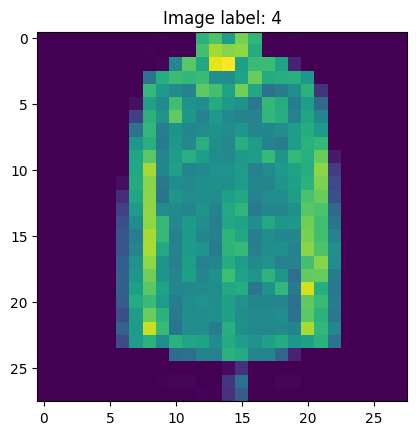

In [38]:
# do not change the code in the block below
# __________start of block__________

train_fmnist_data = FashionMNIST(
    ".", train=True, transform=torchvision.transforms.ToTensor(), download=True
)
test_fmnist_data = FashionMNIST(
    ".", train=False, transform=torchvision.transforms.ToTensor(), download=True
)


train_data_loader = torch.utils.data.DataLoader(
    train_fmnist_data, batch_size=32, shuffle=True, num_workers=2
)

test_data_loader = torch.utils.data.DataLoader(
    test_fmnist_data, batch_size=32, shuffle=False, num_workers=2
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f"Image label: {_label}")
# __________end of block__________

Постройте модель ниже. Пожалуйста, не стройте переусложненную сеть, не стоит делать ее глубже четырех слоев (можно и меньше). Ваша основная задача – обучить модель и получить качество на отложенной (тестовой выборке) не менее 88.5% accuracy.

__Внимание, ваша модель должна быть представлена именно переменной `model_task_1`. На вход ей должен приходить тензор размерностью (1, 28, 28).__

In [39]:
# from src.train.models import *
from typing import Dict, List
from tqdm.auto import tqdm
import torch


def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device,
):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device,
):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device,
) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              test_loss: [...],
              test_acc: [...]}
    For example if training for epochs=2:
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              test_loss: [1.2641, 1.5706],
              test_acc: [0.3400, 0.2973]}
    """
    # Create empty results dictionary
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        test_loss, test_acc = test_step(
            model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device
        )

        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the filled results at the end of the epochs
    return results


def train_to_predict(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device,
) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained.
    train_dataloader: A DataLoader instance for the model to be trained on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training  as well as training accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              test_loss: [...],
              test_acc: [...]}
    For example if training for epochs=2:
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              test_loss: [1.2641, 1.5706],
              test_acc: [0.3400, 0.2973]}
    """
    # Create empty results dictionary
    results = {"train_loss": [], "train_acc": []}

    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )

        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)

    # Return the filled results at the end of the epochs
    return results


def plot_results(results):
    """Plot grah of Loss (train and test) and accuracy (train and loss)

        Args:
            results (dict[list[float]]): Input a dict dict with result of 'train_loss', 'test_loss',
    'train_acc', 'test_acc'.
    """
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(results["train_loss"], label="train")
    plt.plot(results["test_loss"], label="test")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(results["train_acc"], label="train")
    plt.plot(results["test_acc"], label="test")
    plt.title("Acciracy")
    plt.legend()

In [40]:
import torch
import torch.nn as nn


class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Слой 1: Свёртка + ReLU + MaxPooling
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # [1, 28, 28] -> [32, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2),
        )  # -> [32, 14, 14]

        # Слой 2: Свёртка + ReLU + MaxPooling
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [32, 14, 14] -> [64, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2),
        )  # -> [64, 7, 7]

        # Слой 3: Полносвязный
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # -> [128]

        # Слой 4: Выходной (10 классов)
        self.fc2 = nn.Linear(128, 10)  # -> [10]

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [41]:
# Creating model instance
model_task_1 = FashionCNN()

Не забудьте перенести модель на выбранный `device`!

In [42]:
model_task_1.to(device)
model_task_1_state = model_task_1.state_dict()

Локальные тесты для проверки вашей модели доступны ниже:

In [43]:
# do not change the code in the block below
# __________start of block__________
assert (
    model_task_1 is not None
), "Please, use `model_task_1` variable to store your model"

try:
    x = random_batch[0].to(device)
    y = random_batch[1].to(device)

    # compute outputs given inputs, both are variables
    y_predicted = model_task_1(x)
except Exception as e:
    print("Something is wrong with the model")
    raise e


assert y_predicted.shape[-1] == 10, "Model should predict 10 logits/probas"

print("Everything seems fine!")
# __________end of block__________

Everything seems fine!


In [44]:
def get_model_dict_desc(
    model, model_desc, lr, results, state, epochs, train_acc, test_acc
):
    model_dict = {}
    model_dict["model"] = model
    model_dict["desc"] = model_desc
    model_dict["lr"] = lr
    model_dict["results"] = results
    model_dict["state"] = state
    model_dict["epochs"] = epochs
    model_dict["train_acc"] = train_acc
    model_dict["test_acc"] = test_acc

    return model_dict

learning rate:  0.01


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8875 | train_acc: 0.6780 | test_loss: 0.6188 | test_acc: 0.7684
Epoch: 2 | train_loss: 0.5316 | train_acc: 0.8021 | test_loss: 0.5498 | test_acc: 0.7913
Epoch: 3 | train_loss: 0.4468 | train_acc: 0.8377 | test_loss: 0.4441 | test_acc: 0.8341
Epoch: 4 | train_loss: 0.3983 | train_acc: 0.8563 | test_loss: 0.3884 | test_acc: 0.8614
Epoch: 5 | train_loss: 0.3694 | train_acc: 0.8676 | test_loss: 0.3787 | test_acc: 0.8630
Epoch: 6 | train_loss: 0.3477 | train_acc: 0.8752 | test_loss: 0.3869 | test_acc: 0.8617
Epoch: 7 | train_loss: 0.3303 | train_acc: 0.8805 | test_loss: 0.3502 | test_acc: 0.8737
Epoch: 8 | train_loss: 0.3150 | train_acc: 0.8867 | test_loss: 0.3305 | test_acc: 0.8826
Epoch: 9 | train_loss: 0.3012 | train_acc: 0.8911 | test_loss: 0.3287 | test_acc: 0.8806
Epoch: 10 | train_loss: 0.2903 | train_acc: 0.8939 | test_loss: 0.3432 | test_acc: 0.8751
Epoch: 11 | train_loss: 0.2806 | train_acc: 0.8977 | test_loss: 0.3034 | test_acc: 0.8870
Epoch: 12 | train_l

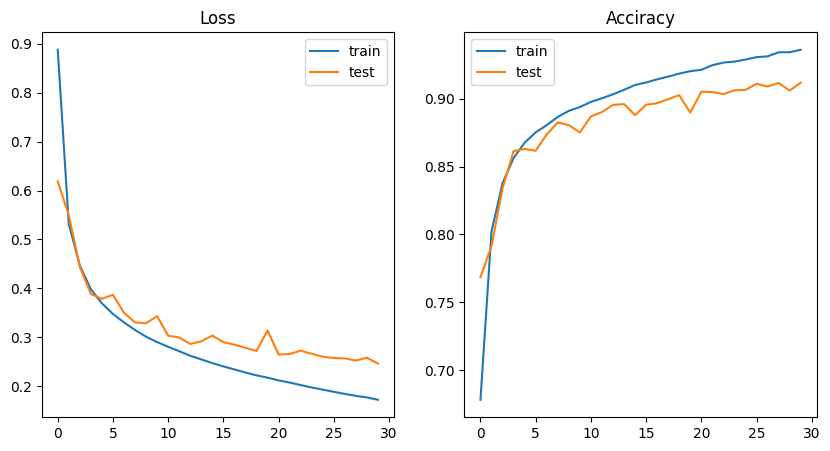

In [45]:
# lr_list = [0.01, 0.05, 0.1, 0.2]
lr_list = [0.01]


epochs = 30
models_list = []


for lr in lr_list:
    print("learning rate: ", lr)
    loss_fn = nn.CrossEntropyLoss()
    model = FashionCNN()
    model.load_state_dict(model_task_1.state_dict())
    optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)

    results = train(
        train_dataloader=train_data_loader,
        test_dataloader=test_data_loader,
        model=model,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        loss_fn=loss_fn,
    )

    train_acc = get_accuracy(model, train_data_loader)
    print(f"Neural network accuracy on train set: {train_acc:3.5}")
    test_acc = get_accuracy(model, test_data_loader)
    print(f"Neural network accuracy on test set: {test_acc:3.5}")

    model_desc = "FashionCNN, lr = {}, epoches = {}".format(lr, epochs)

    md = get_model_dict_desc(
        model="model",
        model_desc=model_desc,
        lr=lr,
        results=results,
        state=model.state_dict(),
        epochs=epochs,
        train_acc=train_acc,
        test_acc=test_acc,
    )
    plot_results(results)

    models_list.append(md)

Настройте параметры модели на обучающей выборке. Также рекомендуем поработать с `learning rate`.

In [46]:
## Выберем лучшую модель по из различных learning rate.

In [47]:
import pandas as pd

df1 = pd.DataFrame(models_list)
df1.columns

Index(['model', 'desc', 'lr', 'results', 'state', 'epochs', 'train_acc',
       'test_acc'],
      dtype='object')

In [48]:
df1[["model", "desc", "lr", "epochs", "train_acc", "test_acc"]]

,model,desc,lr,epochs,train_acc,test_acc
0,model,"FashionCNN, lr = 0.01, epoches = 30",0.01,30,tensor(0.9445),tensor(0.9118)


In [49]:
model_state = df1.iloc[0, 4]
model_task_1.load_state_dict(model_state)

<All keys matched successfully>

Также, напоминаем, что в любой момент можно обратиться к замечательной [документации](https://pytorch.org/docs/stable/index.html) и [обучающим примерам](https://pytorch.org/tutorials/).  

Оценим качество классификации:

In [50]:
train_acc = get_accuracy(model_task_1, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc:3.5}")

Neural network accuracy on train set: 0.94452


In [51]:
test_acc = get_accuracy(model_task_1, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc:3.5}")

Neural network accuracy on test set: 0.9118


Проверка, что необходимые пороги пройдены:

In [52]:
assert test_acc >= 0.885, "Train accuracy is below 0.885 threshold"
assert (
    train_acc >= 0.905
), "Test accuracy is below 0.905 while test accuracy is fine. We recommend to check your model and data flow"

Обращаем внимане, код ниже предполагает, что ваша модель имеет содержится в переменной `model_task_1`.

In [53]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

loaded_data_dict = np.load("hw_overfitting_data_dict.npy", allow_pickle=True)

submission_dict = {
    "train_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["train"])
    ),
    "test_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["test"])
    ),
    "model_task_1": parse_pytorch_model(str(model_task_1)),
}

with open("submission_dict_task_1.json", "w") as iofile:
    json.dump(submission_dict, iofile)
print("File saved to `submission_dict_task_1.json`")
# __________end of block__________

File saved to `submission_dict_task_1.json`


In [54]:
torch.save(model_task_1.state_dict(), "model_task_1.pth")

### Задача №2: Переобучение (Initiation)
Продолжим работу с набором данных [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). Теперь ваша задача продемонстрировать переобучение модели на обучающей выборке. Достаточно показать, что точность классификации (не только функция потерь!) на тестовой выборке значительно отстает от обучающей.

Обращаем ваше внимание, в задаче №3 вам придется починить данную модель (минимизировать эффект переобучения) с помощью механизмов регуляризации, поэтому не переусердствуйте!

__Ваша вторая задача: реализовать используя пайплан обучения модели продемонстрировать переобучения модели на обучающей выборке.__

Код для обучения модели вы можете переиспользовать. Далее присутствует лишь несколько тестов, которые помогут вам проверить свое решение.

Обращаем внимание, вам необходимо использовать переменную `model_task_2` для хранение модели во второй задаче.

Не используйте `Dropout` и `BatchNorm` в этой задаче

In [55]:
class OverfittingModelFMINST(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2048)  # Слишком широкий слой
        self.fc2 = nn.Linear(2048, 2048)  # Ещё один избыточный слой
        self.fc3 = nn.Linear(2048, 10)  # Выходной слой

        # Нет Dropout, BatchNorm или L2-регуляризации

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [56]:
# Creating model instance
model_task_2 = OverfittingModelFMINST()
# your code here

learning rate:  0.2


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5248 | train_acc: 0.8053 | test_loss: 0.4376 | test_acc: 0.8389
Epoch: 2 | train_loss: 0.3743 | train_acc: 0.8621 | test_loss: 0.4142 | test_acc: 0.8389
Epoch: 3 | train_loss: 0.3320 | train_acc: 0.8753 | test_loss: 0.3882 | test_acc: 0.8597
Epoch: 4 | train_loss: 0.3051 | train_acc: 0.8850 | test_loss: 0.3558 | test_acc: 0.8674
Epoch: 5 | train_loss: 0.2852 | train_acc: 0.8919 | test_loss: 0.3524 | test_acc: 0.8722
Epoch: 6 | train_loss: 0.2683 | train_acc: 0.8992 | test_loss: 0.3370 | test_acc: 0.8736
Epoch: 7 | train_loss: 0.2539 | train_acc: 0.9040 | test_loss: 0.3341 | test_acc: 0.8808
Epoch: 8 | train_loss: 0.2393 | train_acc: 0.9084 | test_loss: 0.3265 | test_acc: 0.8840
Epoch: 9 | train_loss: 0.2296 | train_acc: 0.9119 | test_loss: 0.3219 | test_acc: 0.8816
Epoch: 10 | train_loss: 0.2167 | train_acc: 0.9163 | test_loss: 0.3319 | test_acc: 0.8859
Epoch: 11 | train_loss: 0.2106 | train_acc: 0.9191 | test_loss: 0.3140 | test_acc: 0.8930
Epoch: 12 | train_l

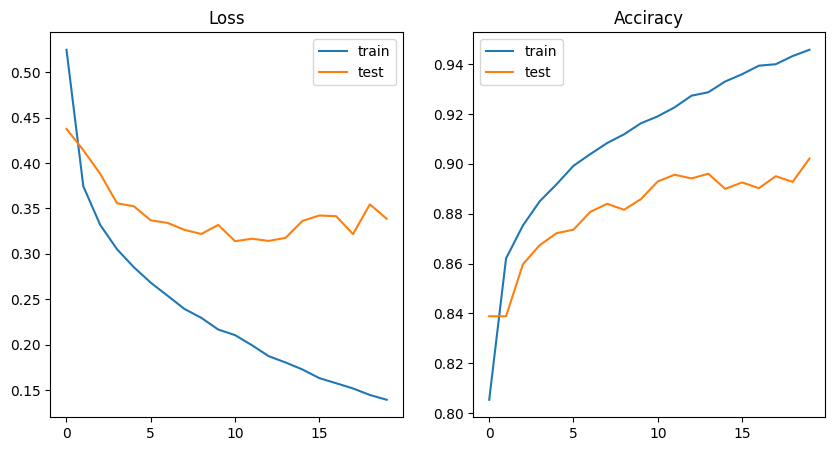

In [57]:
# lr_list = [0.01, 0.05, 0.1, 0.2]
lr_list = [0.2]

epochs = 20
models_list_2 = []


for lr in lr_list:
    print("learning rate: ", lr)
    loss_fn = nn.CrossEntropyLoss()
    model = OverfittingModelFMINST()
    model.load_state_dict(model_task_2.state_dict())
    optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)

    results = train(
        train_dataloader=train_data_loader,
        test_dataloader=test_data_loader,
        model=model,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        loss_fn=loss_fn,
    )

    train_acc = get_accuracy(model, train_data_loader)
    print(f"Neural network accuracy on train set: {train_acc:3.5}")
    test_acc = get_accuracy(model, test_data_loader)
    print(f"Neural network accuracy on test set: {test_acc:3.5}")

    model_desc = "FashionCNN, lr = {}, epoches = {}".format(lr, epochs)

    md = get_model_dict_desc(
        model="model",
        model_desc=model_desc,
        lr=lr,
        results=results,
        state=model.state_dict(),
        epochs=epochs,
        train_acc=train_acc,
        test_acc=test_acc,
    )
    plot_results(results)

    models_list_2.append(md)

Проверка архитектуры:

In [71]:
import pandas as pd

df2 = pd.DataFrame(models_list_2)
print(df2.columns)
df2[["model", "desc", "lr", "epochs", "train_acc", "test_acc"]]

Index(['model', 'desc', 'lr', 'results', 'state', 'epochs', 'train_acc',
       'test_acc'],
      dtype='object')


,model,desc,lr,epochs,train_acc,test_acc
0,model,"FashionCNN, lr = 0.2, epoches = 20",0.2,20,tensor(0.9523),tensor(0.9020)


In [72]:
df2["train_acc"] - df2["test_acc"]

,0
0,tensor(0.0503)


In [70]:
fmodels_list_2[0]['state']

OrderedDict([('fc1.weight',
              tensor([[-0.0061, -0.0090, -0.0271,  ..., -0.0233,  0.0222,  0.0246],
                      [-0.0330, -0.0021, -0.0112,  ...,  0.0316, -0.0222, -0.0309],
                      [ 0.0082,  0.0320,  0.0047,  ..., -0.0067, -0.0241,  0.0151],
                      ...,
                      [ 0.0208,  0.0073,  0.0355,  ...,  0.0171,  0.0322, -0.0120],
                      [ 0.0079, -0.0278, -0.0134,  ...,  0.0683,  0.0516,  0.0103],
                      [-0.0322,  0.0334,  0.0004,  ..., -0.0284, -0.0257,  0.0307]],
                     device='cuda:0')),
             ('fc1.bias',
              tensor([ 0.1597,  0.0054,  0.1157,  ...,  0.0529, -0.3463, -0.0170],
                     device='cuda:0')),
             ('fc2.weight',
              tensor([[ 0.0100,  0.0072,  0.0043,  ...,  0.0166,  0.0349, -0.0070],
                      [-0.0219,  0.0067,  0.0023,  ...,  0.0065, -0.0510, -0.0002],
                      [ 0.0104, -0.0025,  0.0110,  ...,

In [73]:
model_task_2.load_state_dict(df2.iloc[0, 4])
model_task_2.to(device)
# model_task_2.load_state_dict(df2.iloc[3, 4])


OverfittingModelFMINST(
  (fc1): Linear(in_features=784, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=2048, bias=True)
  (fc3): Linear(in_features=2048, out_features=10, bias=True)
)

In [74]:
# do not change the code in the block below
# __________start of block__________
layers_task_2 = []
for element in parse_pytorch_model(str(model_task_2)).get("layers", []):
    layer_name = element["layer"]["type"]
    assert "dropout" not in layer_name.lower(), "Do not use Dropout in Task 2!"
    assert "batchnorm" not in layer_name.lower(), "Do not use BatchNorm in Task 2!"
    layers_task_2.append(layer_name)
# __________end of block__________

Оценим качество классификации:

In [75]:
train_acc_task_2 = get_accuracy(model_task_2, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc_task_2:3.5}")

Neural network accuracy on train set: 0.9523


In [76]:
test_acc_task_2 = get_accuracy(model_task_2, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc_task_2:3.5}")

Neural network accuracy on test set: 0.902


In [77]:
torch.save(model_task_2, "model_task_2.pth")

Проверка, что переобучение присутствует:

In [78]:
assert (
    train_acc_task_2 >= test_acc_task_2
), "Train accuracy must be higher than task accuracy"


assert train_acc_task_2 >= 0.88, "Train accuracy must be higher than 0.88"


assert (
    train_acc_task_2 - test_acc_task_2 >= 0.04
), "Test accuracy should be at least 0.04 lower that train."

Обращаем внимане, код ниже предполагает, что ваша модель имеет содержится в переменной `model_task_2`.

Также предполагается, что в переменной `submission_dict` уже содержатся результаты задачи №1. Если их там нет, загрузите их из сохраненного файла в переменную перед запуском следующей ячейки.

In [79]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

loaded_data_dict = np.load("hw_overfitting_data_dict.npy", allow_pickle=True)

submission_dict.update(
    {
        "train_predictions_task_2": get_predictions(
            model_task_2, torch.FloatTensor(loaded_data_dict.item()["train"])
        ),
        "test_predictions_task_2": get_predictions(
            model_task_2, torch.FloatTensor(loaded_data_dict.item()["test"])
        ),
        "model_task_2": parse_pytorch_model(str(model_task_2)),
    }
)

with open("submission_dict_tasks_1_and_2.json", "w") as iofile:
    json.dump(submission_dict, iofile)
print("File saved to `submission_dict_tasks_1_and_2.json`")
# __________end of block__________

File saved to `submission_dict_tasks_1_and_2.json`


### Задача №3: Исправление модели (Return)
Все так же работаем с [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). Наконец, ваша задача исправить ~~ошибки прошлого~~ переобучение модели, построенной в задаче 2. Достаточно добиться расхождения между точностью классификации на обучающей и тестовой выборках не превышающего 0.015 (т.е. полутора процентов).

Обращаем ваше внимание, архитектура модели в задаче №3 не должна существенно отличаться от задачи №2! Вы можете использовать Batchnorm, Dropout, уменьшить размерность промежуточных представлений, обратиться к аугментации данных, но вы не можете использовать меньшее количество слоёв.

__Ваша третья и финальная задача: исправить модель и/или процесс обучения, дабы справиться с переобучением.__

Код для обучения модели вы можете переиспользовать. Далее присутствует лишь несколько тестов, которые помогут вам проверить свое решение.

Обращаем внимание, вам необходимо использовать переменную `model_task_3` для хранение модели во второй задаче.

Также код ниже будет обращаться к переменной `layers_task_2`, инициализируйте её, если она не определена.

In [80]:
# do not change the code in the block below
# __________start of block__________
assert (
    layers_task_2 is not None
), "Initializa layers_task_2 vairable which contains list of layers in task 2 model"
# __________end of block__________

In [107]:
models_list_3 = []

In [131]:
import torch.nn as nn
import torch.nn.functional as F

class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 2048)
        self.bn1 = nn.BatchNorm1d(2048)  # BatchNorm после первого слоя
        self.dropout1 = nn.Dropout(0.7)   # Dropout 50%

        self.fc2 = nn.Linear(2048, 2048)
        self.bn2 = nn.BatchNorm1d(2048)   # BatchNorm после второго слоя
        self.dropout2 = nn.Dropout(0.3)   # Меньший Dropout

        self.fc3 = nn.Linear(2048, 10)

        # Инициализация весов (Kaiming для ReLU)
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.dropout1(F.relu(self.bn1(self.fc1(x))))  # BN -> ReLU -> Dropout
        x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)  # Нет активации на выходном слое (CrossEntropy включает LogSoftmax)
        return x

class RegularizedModel02(nn.Module):
  def __init__(self):
      super().__init__()
      self.fc1 = nn.Linear(28*28, 1024)
      self.bn1 = nn.BatchNorm1d(1024)  # BatchNorm после первого слоя
      self.dropout1 = nn.Dropout(0.7)   # Dropout 50%

      self.fc2 = nn.Linear(1024, 1024)
      self.bn2 = nn.BatchNorm1d(1024)   # BatchNorm после второго слоя
      self.dropout2 = nn.Dropout(0.3)   # Меньший Dropout

      self.fc3 = nn.Linear(1024, 10)

      # Инициализация весов (Kaiming для ReLU)
      nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
      nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')

  def forward(self, x):
      x = x.view(-1, 28*28)
      x = self.dropout1(F.relu(self.bn1(self.fc1(x))))  # BN -> ReLU -> Dropout
      x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
      x = self.fc3(x)  # Нет активации на выходном слое (CrossEntropy включает LogSoftmax)
      return x


class RegularizedModel03(nn.Module):
  def __init__(self):
      super().__init__()
      self.fc1 = nn.Linear(28*28, 1024)  # Уменьшено с 2048
      self.bn1 = nn.BatchNorm1d(1024)
      self.dropout1 = nn.Dropout(0.7)     # Увеличен Dropout

      self.fc2 = nn.Linear(1024, 512)    # Уменьшено
      self.bn2 = nn.BatchNorm1d(512)
      self.dropout2 = nn.Dropout(0.5)

      self.fc3 = nn.Linear(512, 10)

      # Инициализация весов (Kaiming для ReLU)
      nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
      nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')

  def forward(self, x):
      x = x.view(-1, 28*28)
      x = self.dropout1(F.relu(self.bn1(self.fc1(x))))  # BN -> ReLU -> Dropout
      x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
      x = self.fc3(x)  # Нет активации на выходном слое (CrossEntropy включает LogSoftmax)
      return x

In [132]:
model_task_3 = RegularizedModel03()

learning rate:  0.001


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6032 | train_acc: 0.7840 | test_loss: 0.4427 | test_acc: 0.8354
Epoch: 2 | train_loss: 0.4861 | train_acc: 0.8241 | test_loss: 0.3978 | test_acc: 0.8535
Epoch: 3 | train_loss: 0.4518 | train_acc: 0.8354 | test_loss: 0.3816 | test_acc: 0.8613
Epoch: 4 | train_loss: 0.4296 | train_acc: 0.8437 | test_loss: 0.3702 | test_acc: 0.8643
Epoch: 5 | train_loss: 0.4102 | train_acc: 0.8515 | test_loss: 0.3638 | test_acc: 0.8652
Epoch: 6 | train_loss: 0.3996 | train_acc: 0.8546 | test_loss: 0.3539 | test_acc: 0.8721
Epoch: 7 | train_loss: 0.3874 | train_acc: 0.8593 | test_loss: 0.3402 | test_acc: 0.8779
Epoch: 8 | train_loss: 0.3769 | train_acc: 0.8621 | test_loss: 0.3457 | test_acc: 0.8726
Epoch: 9 | train_loss: 0.3701 | train_acc: 0.8654 | test_loss: 0.3386 | test_acc: 0.8756
Epoch: 10 | train_loss: 0.3584 | train_acc: 0.8697 | test_loss: 0.3289 | test_acc: 0.8813
Epoch: 11 | train_loss: 0.3535 | train_acc: 0.8695 | test_loss: 0.3276 | test_acc: 0.8799
Epoch: 12 | train_l

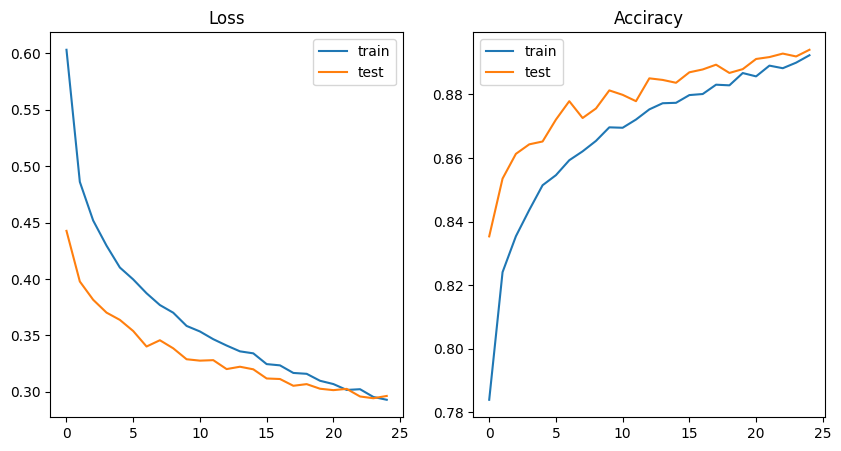

In [141]:
# lr_list = [0.01, 0.05, 0.1, 0.2]
lr_list = [1e-3]

epochs = 25

for lr in lr_list:
    print("learning rate: ", lr)
    loss_fn = nn.CrossEntropyLoss()
    model = RegularizedModel03()
    model.load_state_dict(model_task_3.state_dict())
    # optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)


    results = train(
        train_dataloader=train_data_loader,
        test_dataloader=test_data_loader,
        model=model,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        loss_fn=loss_fn,
    )

    train_acc = get_accuracy(model, train_data_loader)
    print(f"Neural network accuracy on train set: {train_acc:3.5}")
    test_acc = get_accuracy(model, test_data_loader)
    print(f"Neural network accuracy on test set: {test_acc:3.5}")

    model_desc = "RegularizedModel03, torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4), lr = {}, epoches = {}".format(lr, epochs)

    md = get_model_dict_desc(
        model="model",
        model_desc=model_desc,
        lr=lr,
        results=results,
        state=model.state_dict(),
        epochs=epochs,
        train_acc=train_acc,
        test_acc=test_acc,
    )
    plot_results(results)

    models_list_3.append(md)

In [149]:
models_list_3[4]['state']

OrderedDict([('fc1.weight',
              tensor([[-0.2923, -0.3336, -0.4565,  ...,  0.0867,  0.0110, -0.2568],
                      [-0.2544,  0.2637,  0.1027,  ..., -0.2421, -0.4780, -0.6713],
                      [ 0.2022,  0.0331, -0.0150,  ...,  0.4258,  0.4583,  0.0075],
                      ...,
                      [ 0.2292, -0.2076,  0.2925,  ...,  0.1299,  0.2041,  0.2817],
                      [ 0.0884,  0.0793, -0.2840,  ...,  0.1343, -0.1388, -0.0947],
                      [-0.1567,  0.0599,  0.4509,  ..., -0.5056, -0.2856,  0.0953]],
                     device='cuda:0')),
             ('fc1.bias',
              tensor([-1.7457e-02, -4.5393e-05,  2.9684e-02,  ..., -4.6316e-03,
                       4.6178e-03,  3.1735e-02], device='cuda:0')),
             ('bn1.weight',
              tensor([1.0116, 0.8181, 0.9383,  ..., 1.0239, 0.6263, 1.0227], device='cuda:0')),
             ('bn1.bias',
              tensor([-0.5750, -0.4453, -0.2614,  ..., -0.5465, -0.3715, -0.

In [1]:
epochs = 15
lr = 1e-3

model = RegularizedModel03()

model.load_state_dict(models_list_3[4]['state'])

# model = RegularizedModel03()
# model.load_state_dict(model_task_3.state_dict())
# optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)


results = train(
    train_dataloader=train_data_loader,
    test_dataloader=test_data_loader,
    model=model,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
    loss_fn=loss_fn,
)

train_acc = get_accuracy(model, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc:3.5}")
test_acc = get_accuracy(model, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc:3.5}")

model_desc = "RegularizedModel03, torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4), lr = {}, epoches = {}".format(lr, epochs)

md = get_model_dict_desc(
    model="model",
    model_desc=model_desc,
    lr=lr,
    results=results,
    state=model.state_dict(),
    epochs=epochs,
    train_acc=train_acc,
    test_acc=test_acc,
)
plot_results(results)

models_list_3.append(md)

NameError: name 'RegularizedModel03' is not defined

In [147]:
df3 = pd.DataFrame(models_list_3)
print(df3.columns)
df3[["model", "desc", "lr", "epochs", "train_acc", "test_acc"]]

Index(['model', 'desc', 'lr', 'results', 'state', 'epochs', 'train_acc',
       'test_acc'],
      dtype='object')


,model,desc,lr,epochs,train_acc,test_acc
0,model,"RegularizedModel, lr = 0.1, epoches = 25",0.100,25,tensor(0.9272),tensor(0.8902)
1,model,"RegularizedModel, lr = 0.1, epoches = 3",0.100,3,tensor(0.9284),tensor(0.8920)
2,model,"RegularizedModel02, lr = 0.1, epoches = 25",0.100,25,tensor(0.9182),tensor(0.8886)
3,model,"RegularizedModel03, lr = 0.1, epoches = 30",0.100,30,tensor(0.9204),tensor(0.8882)
4,model,"RegularizedModel03, torch.optim.AdamW(model.pa...",0.001,25,tensor(0.9218),tensor(0.8940)


In [144]:
df3['train_acc'] - df3['test_acc']

,0
0,tensor(0.0370)
1,tensor(0.0364)
2,tensor(0.0296)
3,tensor(0.0322)
4,tensor(0.0278)


In [113]:
model_task_3.load_state_dict(df3.iloc[0, 4])
model_task_3.to(device)

RegularizedModel(
  (fc1): Linear(in_features=784, out_features=2048, bias=True)
  (bn1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.7, inplace=False)
  (fc2): Linear(in_features=2048, out_features=2048, bias=True)
  (bn2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=2048, out_features=10, bias=True)
)

Проверка архитектуры:

In [114]:
# do not change the code in the block below
# __________start of block__________
layers_task_3 = []
for element in parse_pytorch_model(str(model_task_3)).get("layers", []):
    layer_name = element["layer"]["type"]
    layers_task_3.append(layer_name)


idx = 0
for model_3_layer in layers_task_3:
    model_2_layer = layers_task_2[idx]
    if (
        "dropout" not in model_3_layer.lower()
        and "batchnorm" not in model_3_layer.lower()
    ):
        assert (
            model_3_layer == model_2_layer
        ), "Models in tasks 2 and 3 must share the architecture except for Dropout and BatchNorm!"
        idx += 1
# __________end of block__________

Оценим качество классификации:

In [115]:
train_acc_task_3 = get_accuracy(model_task_3, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc_task_3:3.5}")

Neural network accuracy on train set: 0.92717


In [116]:
test_acc_task_3 = get_accuracy(model_task_3, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc_task_3:3.5}")

Neural network accuracy on test set: 0.8902


Проверка, что переобучение присутствует:

In [117]:
assert train_acc_task_3 >= 0.88, "Train accuracy must be higher than 0.88"
assert train_acc_task_3 >= 0.865, "Test accuracy must be higher than 0.865"
assert (
    train_acc_task_3 - test_acc_task_3 <= 0.015
), "Test accuracy should not be lower that train more than by 0.015"

AssertionError: Test accuracy should not be lower that train more than by 0.015

Обращаем внимане, код ниже предполагает, что ваша модель имеет содержится в переменной `model_task_3`.

Также предполагается, что в переменной `submission_dict` уже содержатся результаты задач №1 и №2. Если их там нет, загрузите их из сохраненных файлов перед запуском следующей ячейки.

In [ ]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

loaded_data_dict = np.load("hw_overfitting_data_dict.npy", allow_pickle=True)

submission_dict.update(
    {
        "train_predictions_task_3": get_predictions(
            model_task_3, torch.FloatTensor(loaded_data_dict.item()["train"])
        ),
        "test_predictions_task_3": get_predictions(
            model_task_3, torch.FloatTensor(loaded_data_dict.item()["test"])
        ),
        "model_task_3": parse_pytorch_model(str(model_task_3)),
    }
)

with open("submission_dict_final.json", "w") as iofile:
    json.dump(submission_dict, iofile)
print("File saved to `submission_dict_final.json`")
# __________end of block__________

### Сдача задания
Сдайте сгенерированные файлы в соответствующие задачи в соревновании, а именно:
* `submission_dict_tasks_1_and_2.json` в задачу Initiation
* `submission_dict_final.json` в задачу Return.


`submission_dict_task_1.json` сдавать не нужно, он уже был сдан ранее.

На этом задание завершено. Поздравляем!